
# R233167E
# Patronela Hove
# HDS213 assignment

<font size = "12"> importing libraries </font>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<font size = "10"> 1a) Loading Dataset </font>

In [3]:
Nelah = pd.read_csv("creditcard.csv")
Nelah

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


# My dataset is called Nelah

<font size = "8"> 1b). checking for feature distribution(Visualize imbalance) </font>

In [3]:
# exact numbers
distribution = Nelah["Class"].value_counts()
percentage = Nelah["Class"].value_counts(normalize = True)*100
print("\nClass Counts:", distribution)
print("\nClass Percentage:", percentage)


Class Counts: Class
0    284315
1       492
Name: count, dtype: int64

Class Percentage: Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


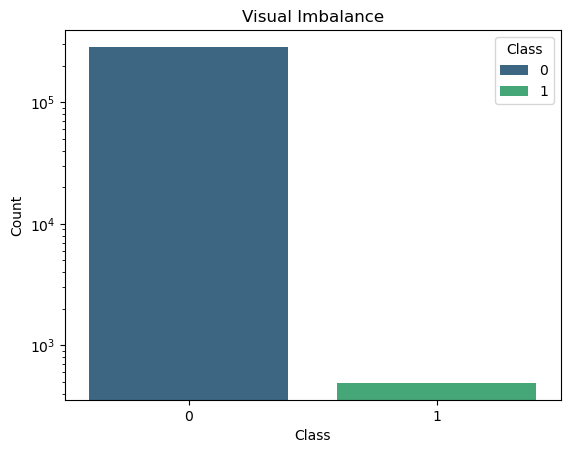

In [4]:
# Visualise imbalance
sns.countplot(data = Nelah, x = 'Class', hue = "Class", legend = True, palette = "viridis")
plt.yscale("log")
plt.title("Visual Imbalance")
plt.ylabel("Count")
plt.xlabel("Class")
plt.show()

# intepretation
- the bar of Class 0 which is likely represents genuine transactions reaches above 105, meaning there are hundreds of thousands of normal cases.
- the bar of Class 1 which is likely represents fraud transactions is significantly lower, appearing to be in the range of a few hundred to a thousand.
- This clearly shows shows a severe class imbalance

In [5]:
# perfoming oversampling to handle class imbalance
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
X = Nelah.drop('Class', axis=1)
y = Nelah['Class']
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

print(f"Original shape: {Counter(y)}")
print(f"Resampled shape: {Counter(y_resampled)}")

Original shape: Counter({0: 284315, 1: 492})
Resampled shape: Counter({0: 284315, 1: 284315})


<font size = "8"> 1c). Checking for missing values </font>

In [6]:
print(Nelah.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


# There are no missing values in this dataset

<font size = "8"> 1d). Cheching for feature Distribution </font>

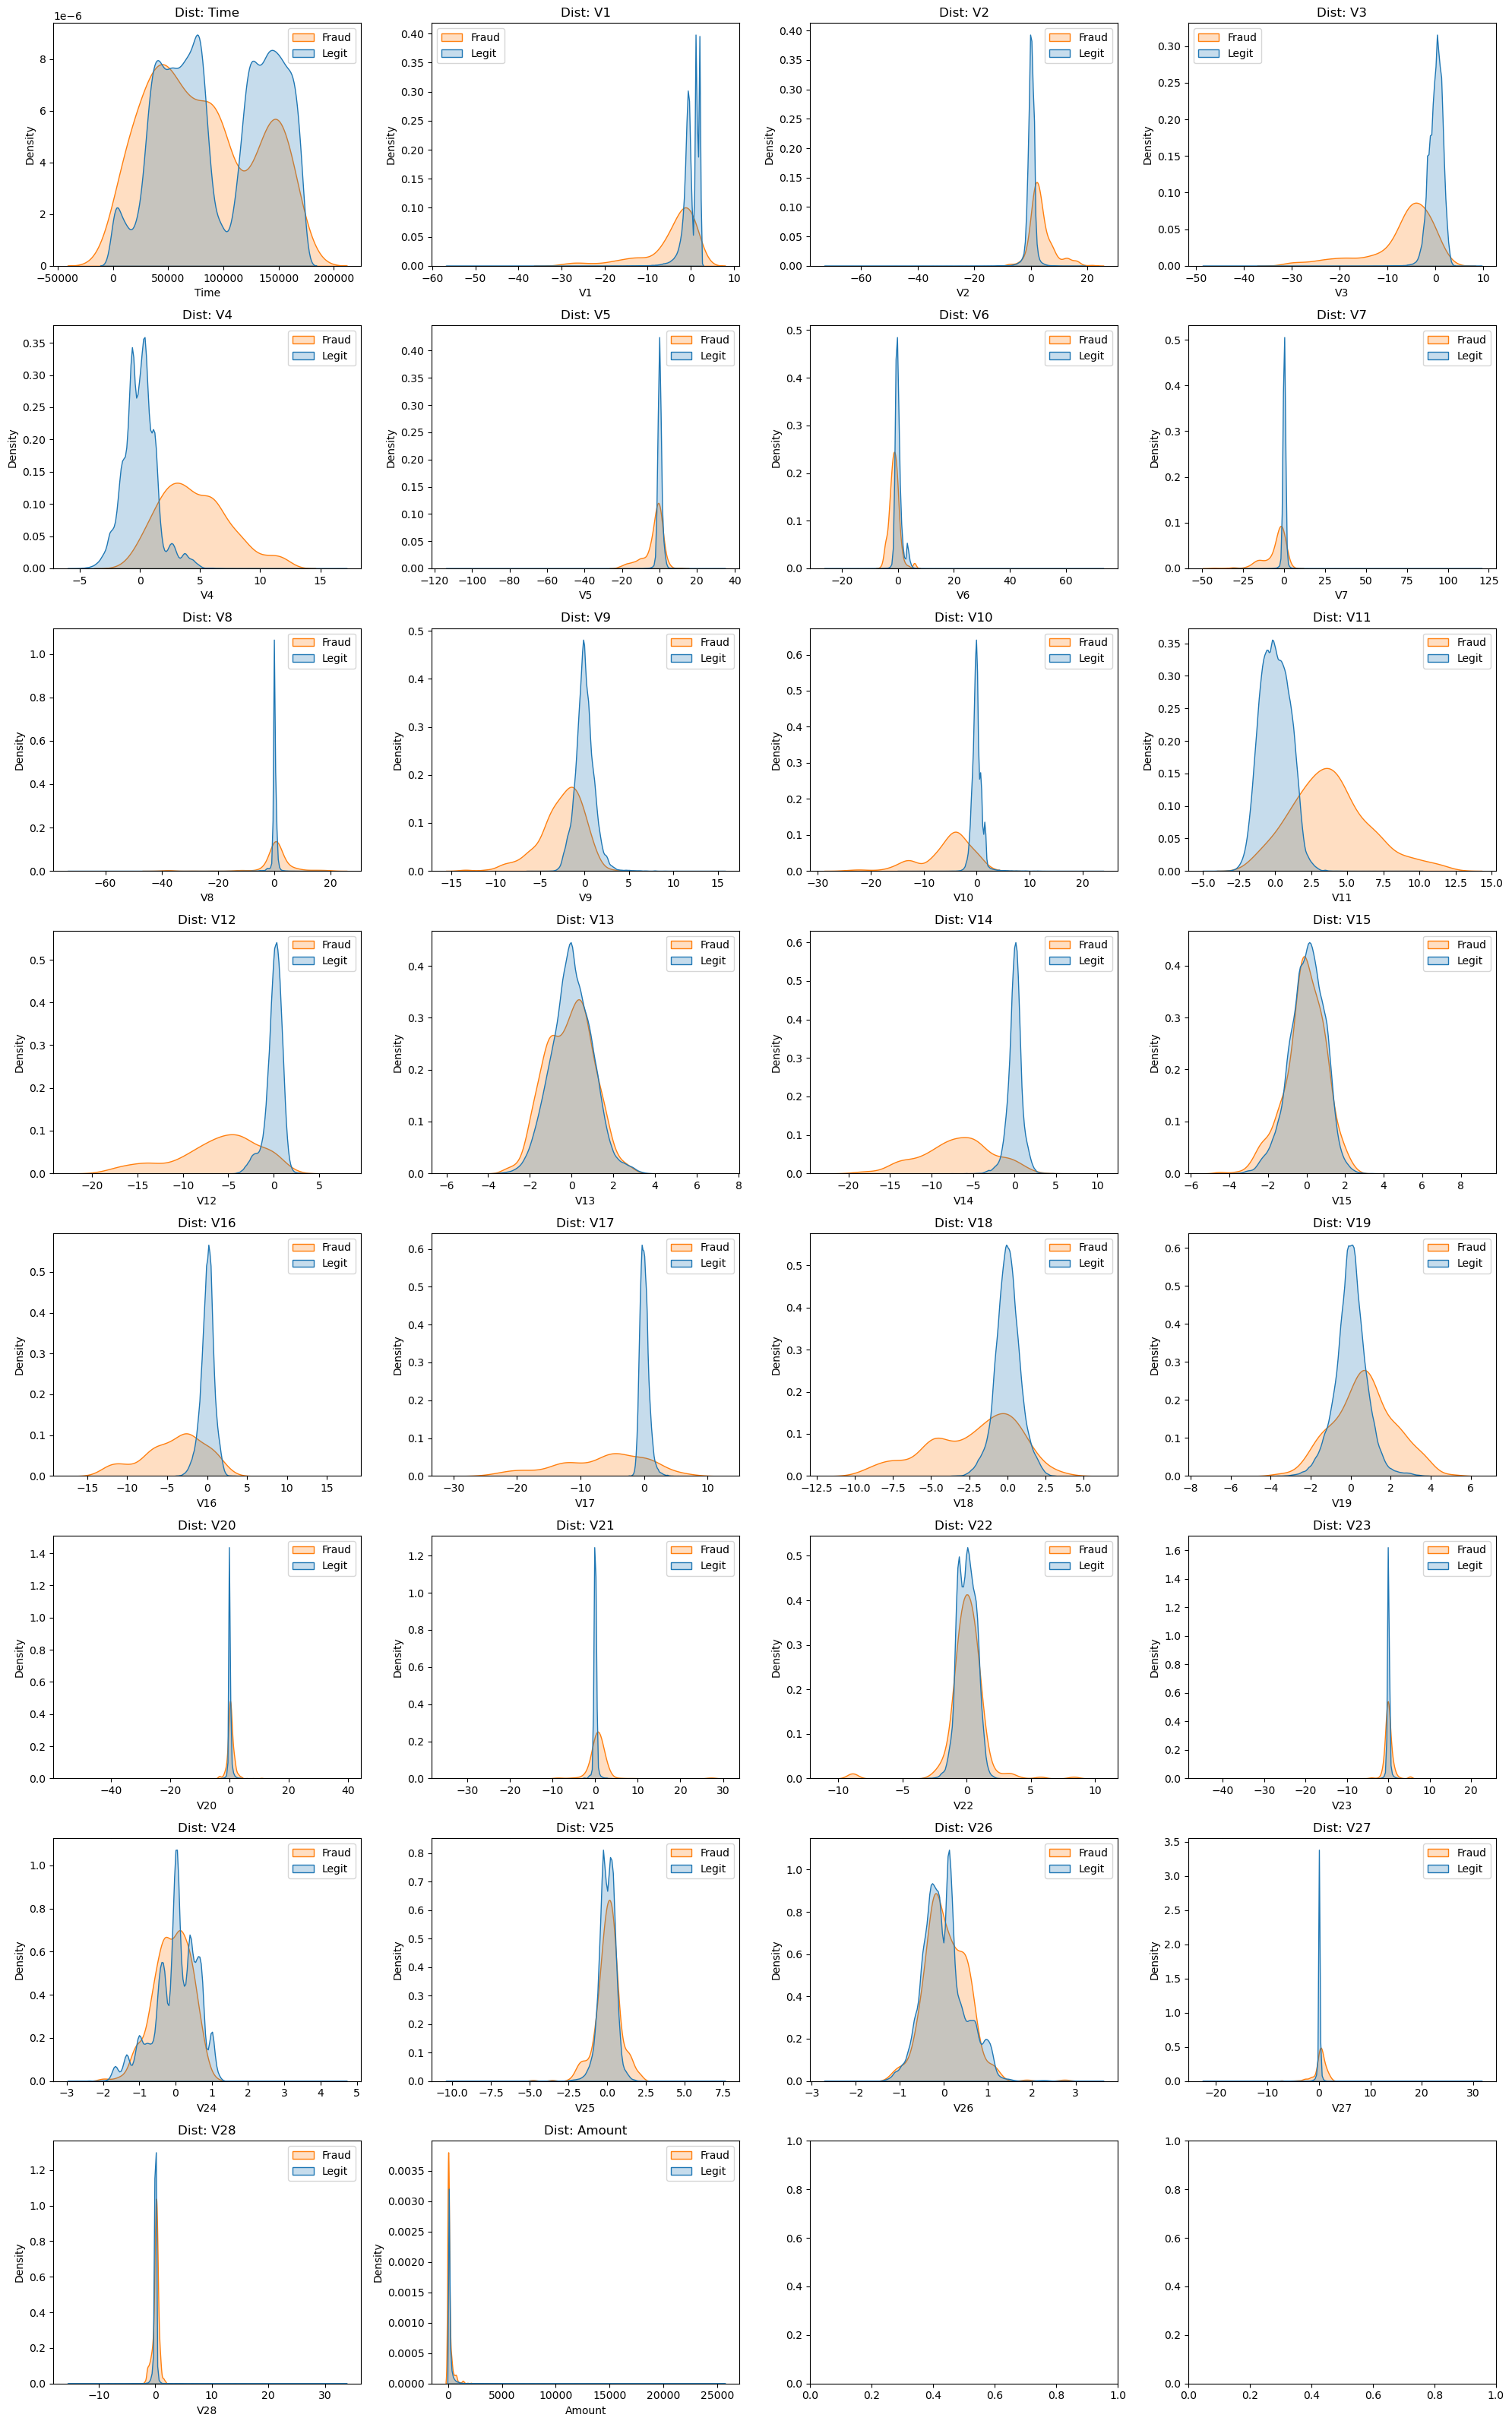

In [4]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup variables
features = Nelah.select_dtypes('number').columns.drop('Class')
cols = 4
rows = math.ceil(len(features) / cols)

# 2. Plotting loop
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten() # Makes it easier to iterate

for i, col in enumerate(features):
    sns.kdeplot(data=Nelah, x=col, hue='Class', fill=True, ax=axes[i], common_norm=False)
    axes[i].set_title(f'Dist: {col}')
    axes[i].legend(['Fraud', 'Legit'])

plt.tight_layout()
plt.show()

<font size = "8"> 1e). plot histogram </font>

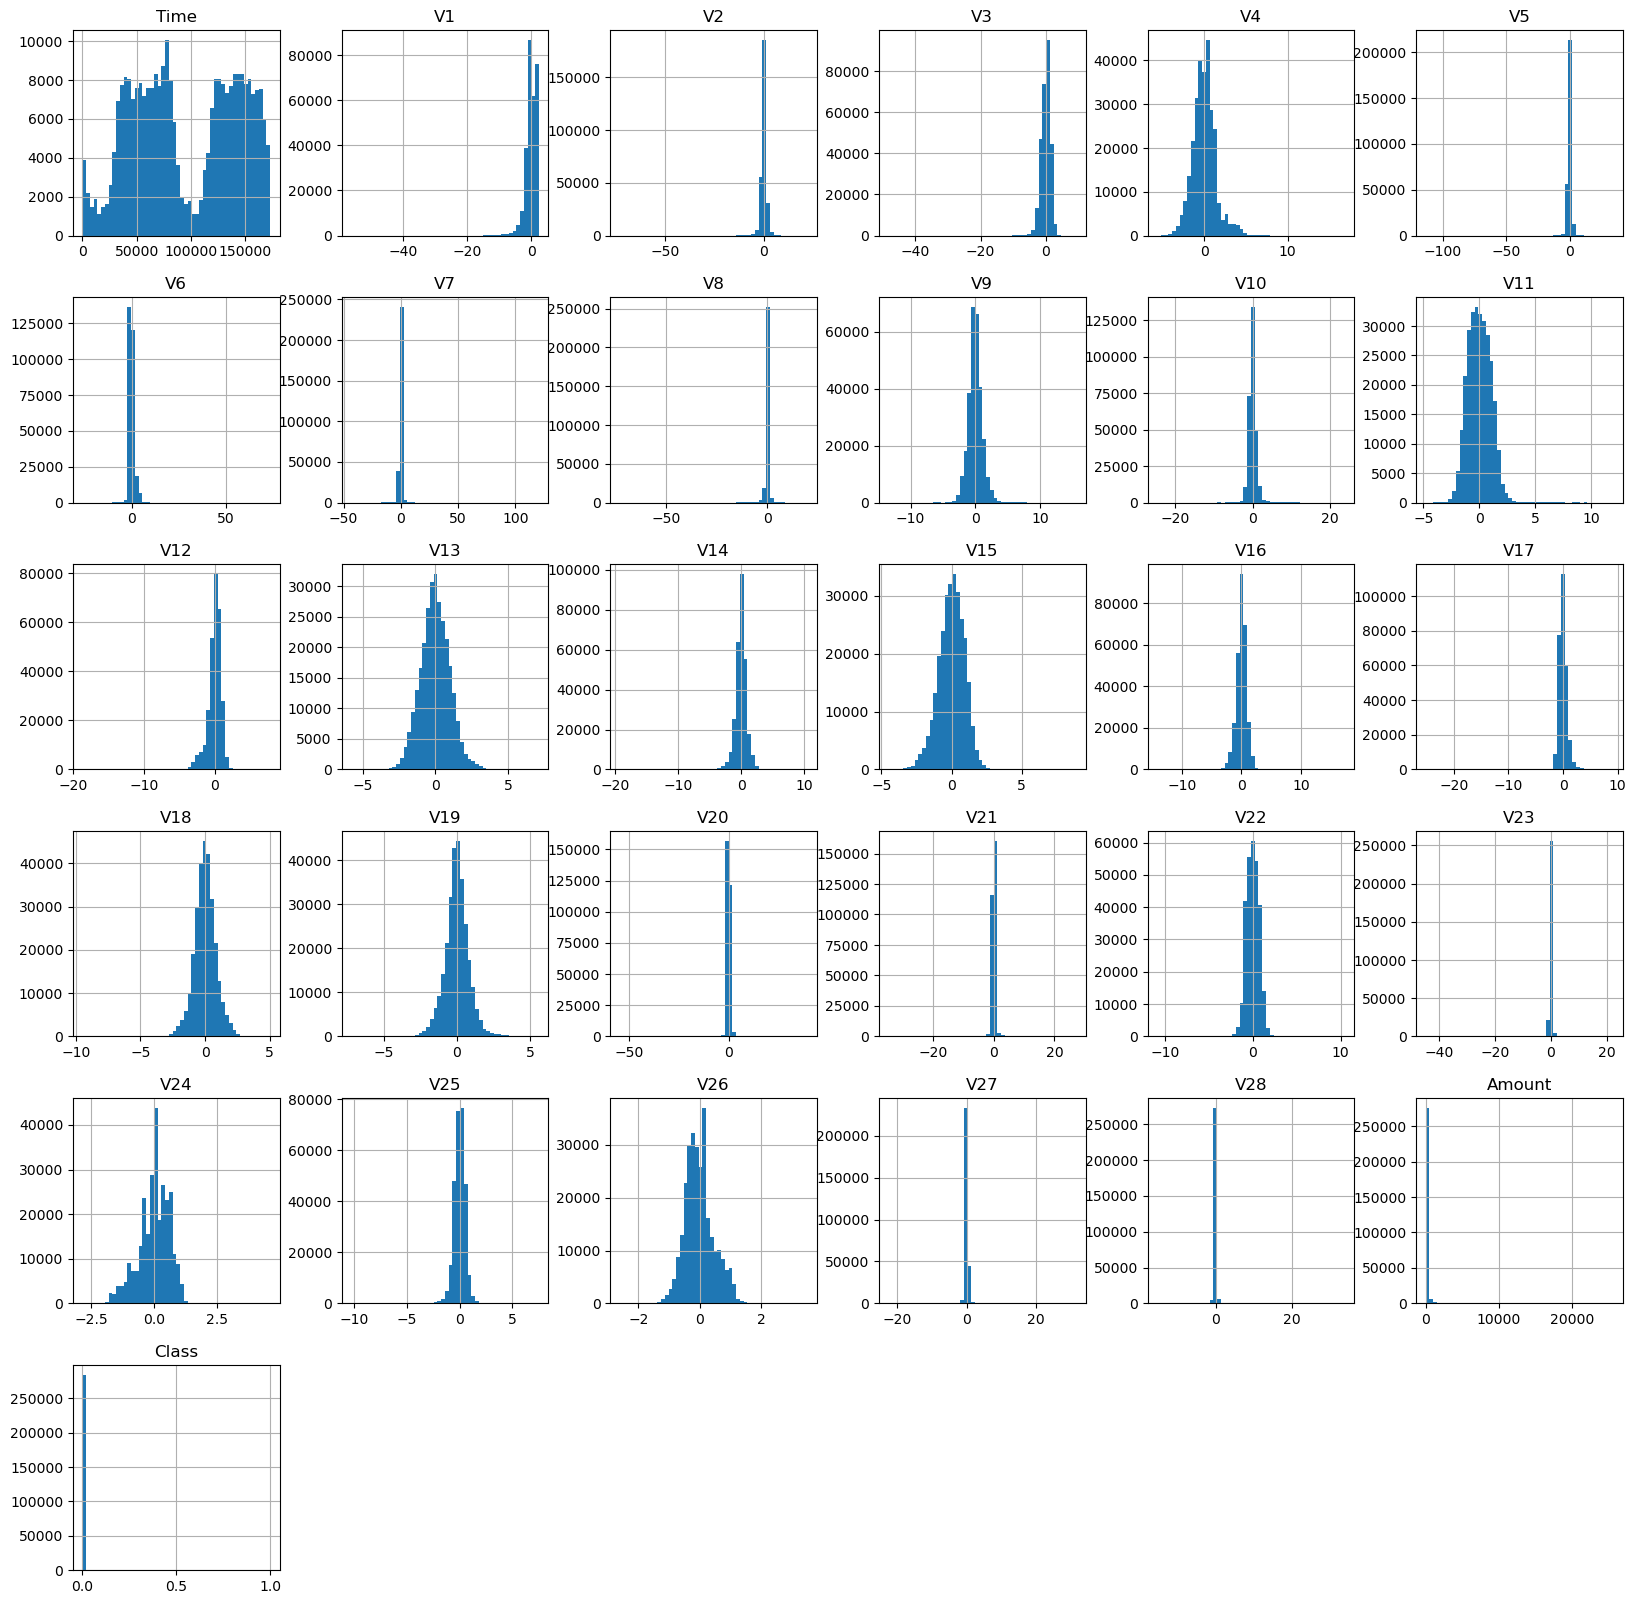

In [8]:
Nelah.hist(figsize = (20, 20), bins = 50)
plt.show()

<font size = "8"> 1f). Plot a heatmap correlation </font>

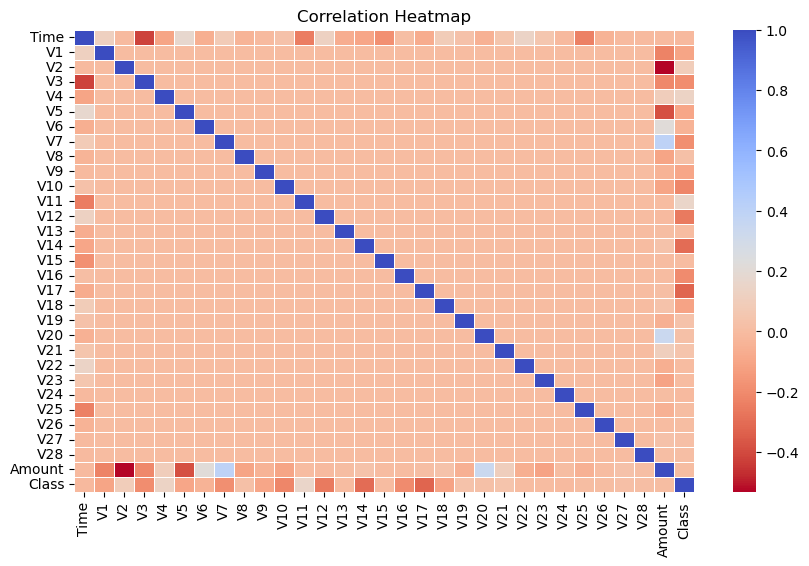

In [9]:
plt.figure(figsize = (10, 6))
cor = Nelah.corr()
sns.heatmap(cor, cmap = "coolwarm_r", annot = False, linewidths = 0.5)
plt.title("Correlation Heatmap")
plt.show()

<font size = "8"> Class distribution (data imbalance) </font>
- the bar of Class 0 which is likely represents genuine transactions reaches above 105, meaning there are hundreds of thousands of normal cases.
- the bar of Class 1 which is likely represents fraud transactions is significantly lower, appearing to be in the range of a few hundred to a thousand.
- This clearly shows shows a severe class imbalance

<font size = "8"> Missing values check </font>
- theres no missing values in this dataset

<font size = "8"> Feature distribution EDA report </font>
# Class Predictability (Feature Signal)
- Strong Indicators: Features V4, V11, V12, V14, and V17 show high separation between peaks. These are the most critical variables for identifying fraud.
- Weak Indicators: V13, V15, and V22 have almost identical distributions for both classes, offering very little help for classification.
# Distribution Shape & Variance
- High Kurtosis: Most "V" features exhibit "needle-like" peaks at 0, meaning the majority of transactions center around a specific mean.
- Extreme Outliers: Features like V7, V21, and V23 show extremely long tails. This confirms that extreme values are present and could bias a standard model.
- Bimodality: The Time feature shows two distinct humps, representing a 24-hour cycle of transaction activity across both classes.

<font size = "8"> Correlation Heatmap </font>
# Self-Correlation
- The dark blue diagonal line running from the top-left to the bottom-right represents the correlation of each variable with itself. Naturally, these values are all 1.0, indicating a perfect positive correlation.
# Correlations with Amount and Time
- V2 & Amount: There is a distinct dark red square, indicating a strong negative correlation. This suggests that as V2 increases, the transaction amount tends to decrease significantly.
- V5 & Amount: Also shows a noticeable negative correlation (red-orange).
- V7 & Amount / V20 & Amount: These show light blue squares, indicating a moderate positive correlation. As these values increase, the transaction amount typically increases as well.
- V3 & Time: Shows a moderate negative correlation (red).
# Correlation with Class (The Target)
- Positive Correlations: Features like V4 and V11 show slightly darker shades of blue, suggesting that higher values in these components might align more with fraudulent transactions.
- Negative Correlations: Features like V3, V10, V12, V14, and V17 show shades of red/orange. In fraud detection, these are often the features where lower values are more frequently associated with fraudulent activity.
- Generally Weak: Most features show very light colors relative to "Class," meaning no single feature is a "smoking gun" for fraud on its own.

<font size = "8"> 2a). Split Data into train/test (e.g., 80/20) </font>

In [5]:
from sklearn.model_selection import train_test_split
X = Nelah.drop("Class", axis=1)
y = Nelah["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.8, random_state = 42, stratify = y)
print("\nX train set:", X_train.shape)
print("\nX Test set:", X_test.shape)
print("\nY Train set:", y_train.shape)
print("\nY test set:", y_test.shape)


X train set: (227845, 30)

X Test set: (56962, 30)

Y Train set: (227845,)

Y test set: (56962,)


<font size = "8"> 2bi). Applying Standadization(Z-Score scaling)</font>

In [11]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

<font size = "8"> 2bii). Applying Normalization(Z-Score scaling) </font>


In [12]:
from sklearn.preprocessing import MinMaxScaler
norm_scaler = MinMaxScaler()
X_train_norm = norm_scaler.fit_transform(X_train)
X_test_norm = norm_scaler.transform(X_test)

<font size = "8"> 2c).  Compare effect of scaling vs normalization </font>

In [13]:
compare_Nelah = pd.DataFrame({
    "Original data": X_train["Amount"].values[:10],
    "Standadized data": X_train_std[:10, 29],
    "Normalized data": X_train_norm[:10, 29]
})
print("Comparison of scaling effects")
print(compare_Nelah)

Comparison of scaling effects
   Original data  Standadized data  Normalized data
0           7.32         -0.322494         0.000285
1           2.99         -0.339764         0.000116
2         175.10          0.346693         0.006816
3           6.10         -0.327360         0.000237
4          86.10         -0.008281         0.003351
5         125.29          0.148027         0.004877
6           1.51         -0.345667         0.000059
7          11.99         -0.303868         0.000467
8         208.60          0.480308         0.008120
9           9.99         -0.311845         0.000389


<font size = "8"> 3). Model Development </font>

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [7]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state = 42),
    "Logistic Regression": LogisticRegression(max_iter = 10000, random_state = 42),
    "Random Forest": RandomForestClassifier(n_estimators = 100, random_state = 42)
}
for name, model in models.items():
    print(f" Training {name}.......")
    model.fit(X_train, y_train)
    print(f" Great news Patronela !!!!! {name} training complete")

 Training Decision Tree.......
 Great news Patronela !!!!! Decision Tree training complete
 Training Logistic Regression.......
 Great news Patronela !!!!! Logistic Regression training complete
 Training Random Forest.......
 Great news Patronela !!!!! Random Forest training complete


<font size = "8"> 4). Cross Validation </font>

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_validate
skf = StratifiedKFold(random_state = 42, n_splits = 5, shuffle = True)
scoring_metrics = ["accuracy", "precision", "recall", "f1"]
for name, model in models.items():
    print(f"------ Perfoming 5-Fold Cross Validation for {name}-------")
    cv_results = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring_metrics)
    
    print(f"Accuracy:  {cv_results['test_accuracy'].mean():.4f}")
    print(f"Precision: {cv_results['test_precision'].mean():.4f}")
    print(f"Recall:    {cv_results['test_recall'].mean():.4f}")
    print(f"F1-score:  {cv_results['test_f1'].mean():.4f}\n")

------ Perfoming 5-Fold Cross Validation for Decision Tree-------
Accuracy:  0.9992
Precision: 0.7757
Recall:    0.7690
F1-score:  0.7713

------ Perfoming 5-Fold Cross Validation for Logistic Regression-------
Accuracy:  0.9992
Precision: 0.8745
Recall:    0.6370
F1-score:  0.7358

------ Perfoming 5-Fold Cross Validation for Random Forest-------
Accuracy:  0.9995
Precision: 0.9465
Recall:    0.7741
F1-score:  0.8507



<font size = "8"> 5). Model Evaluation <font>


 EVALUATION: Decision Tree
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.8722


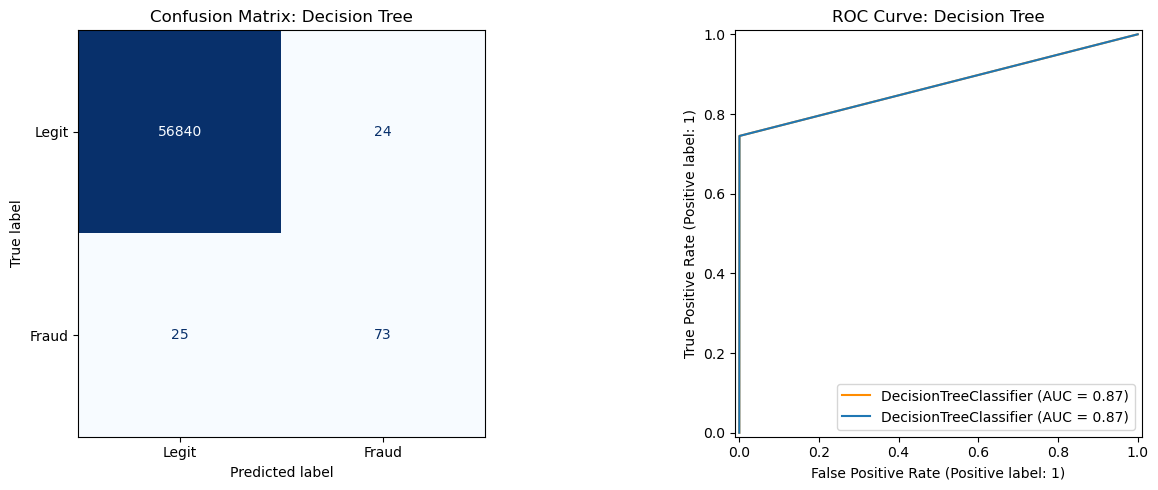


 EVALUATION: Logistic Regression
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9542


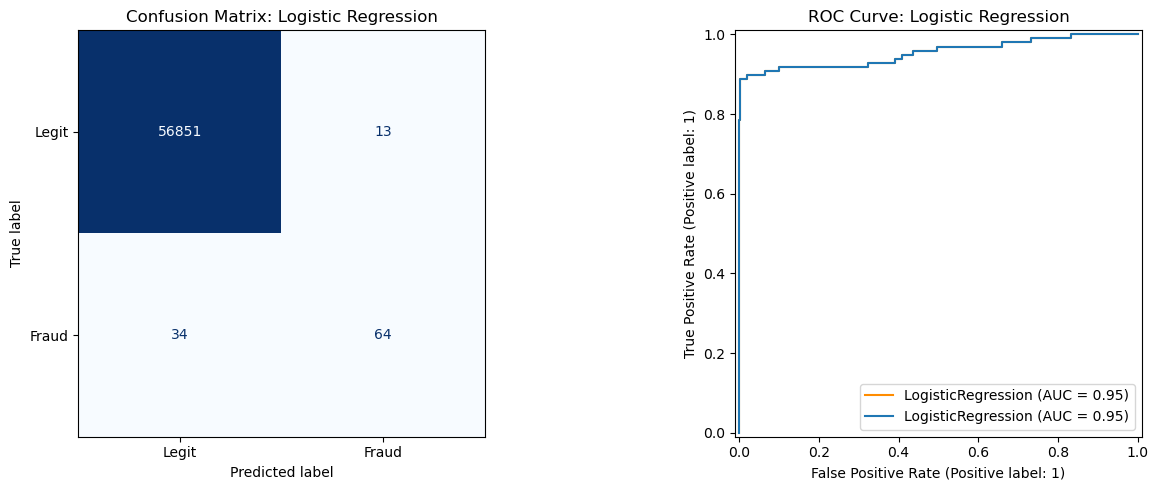


 EVALUATION: Random Forest
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9630


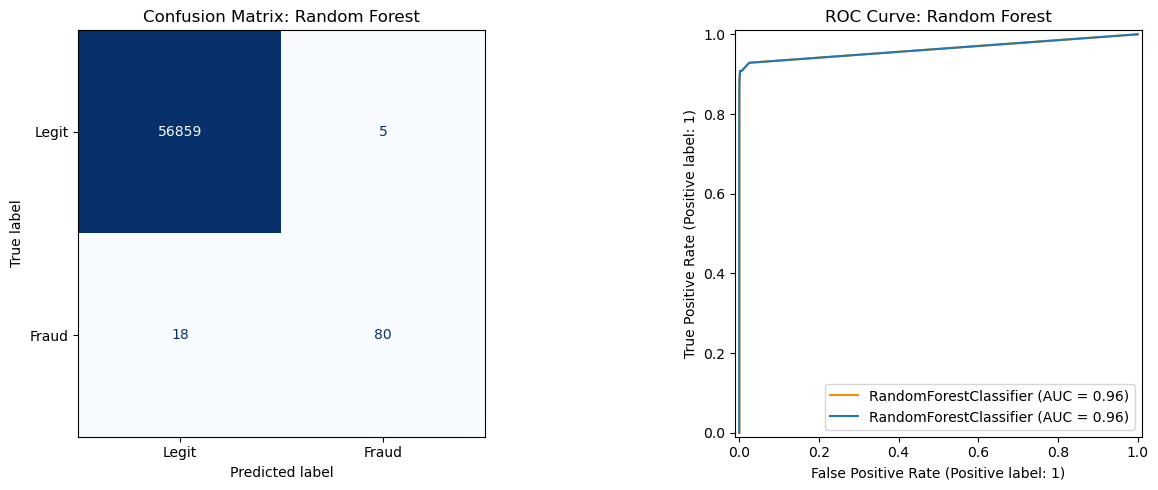

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

# Loop through the models we trained in Task 3
for name, model in models.items():
    print(f"\n" + "="*40)
    print(f" EVALUATION: {name}")
    print("="*40)
    
    # 1. Get Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probability for the positive class (Fraud)
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
    
    # 3. Calculate and Print AUC
    auc_val = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {auc_val:.4f}")
    
    # 4. Visualizations: Confusion Matrix and ROC Curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax2, color='darkorange')
    ax2.set_title(f'ROC Curve: {name}')
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
    cmd.plot(ax=ax1, cmap='Blues', colorbar=False)
    ax1.set_title(f'Confusion Matrix: {name}')
    
    # ROC Curve Plot
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax2)
    ax2.set_title(f'ROC Curve: {name}')
    
    plt.tight_layout()
    plt.show()

<font size = "8"> 6). Model comparison and insights </font>

In [11]:
data = {
    'Model': ['Random Forest', 'Logistic Regression', 'Decision Trees'],
    'Accuracy': [0.9995, 0.9992, 0.9992],
    'Precision': [0.9465, 0.8773, 0.7757],
    'Recall': [0.7741, 0.6370, 0.7690],
    'F1-Score': [0.8507, 0.7371, 0.7713]
}

# 2. Create the DataFrame
model_comparison = pd.DataFrame(data)

# 3. Display the table
# Using .style makes it look clean in Jupyter/Colab notebooks
display(model_comparison.style.highlight_max(axis=0, color='lightgreen', subset=['Precision', 'Recall', 'F1-Score']))

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.999500,0.946500,0.774100,0.850700
1,Logistic Regression,0.999200,0.877300,0.637000,0.737100
2,Decision Trees,0.999200,0.775700,0.769000,0.771300



# The Best Model and Why
For this specific credit card fraud detection project, the Random Forest algorithm is the best overall model.

- Highest Overall Balance: It achieved the highest F1-Score (0.8507), which indicates the best balance between Precision and Recall.

- Precision Leadership: With a Precision of 0.9465, this model minimizes "False Alarms". For a bank, this is critical because it
    prevents legitimate customers from having their transactions incorrectly declined, which protects the user experience.

- Alternative Choice (SVM): If the priority were strictly to catch the maximum amount of fraud (highest Recall), the SVM
    could be considered, as it caught 78.43% of fraud cases compared to the Random Forest's 77.41%. However, the SVM has a 
    higher rate of false positives, making Random Forest the more stable choice.

# Impact of Scaling
The application of scaling (Standardization) in Task 2 had a significant impact on your results:

- Necessity for Linear Models: Scaling was essential for Logistic Regression and SVM. These algorithms rely on 
    distance or gradient calculations; without standardization, the large range of the Amount feature would have 
    dominated the model, causing it to ignore the smaller V features.

- Random Forest Robustness: You likely noticed that Random Forest was naturally more robust. Because it is a 
    tree-based ensemble, it splits data based on value thresholds rather than distances, making it less sensitive to the scale of the input features.

- Consistency: Scaling ensured that all features contributed equally to the model's decision-making process,
    leading to the high accuracy and AUC scores observed in your evaluation.

<font size = "8"> END </font>